# 02 — Road classes, clipping, and quality

Primary roads alone omit secondary, local, residential, and rural access.
This notebook studies three cumulative networks rather than selecting one
arbitrary class.

In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

data_root = Path(os.environ.get("BENCHMARK_DATA_DIR", "/benchmark-data"))
roads_path = data_root / "canonical" / "israel_roads.parquet"
if not roads_path.exists():
    raise FileNotFoundError("Run ./benchmark.sh prepare roads first")
roads = gpd.read_parquet(roads_path)
roads.head(3)

,road_id,source_segment_id,road_class,is_arterial,is_general_driving,is_service_rural,geometry,length_m
0,001622f7-1039-4b6e-8ac3-aa2d137972c9#0,001622f7-1039-4b6e-8ac3-aa2d137972c9,living_street,False,True,True,"LINESTRING (35.21943 31.78118, 35.2194 31.7816...",153.394401
1,003fdace-5ce9-4f12-911c-d3bd9b248a07#0,003fdace-5ce9-4f12-911c-d3bd9b248a07,living_street,False,True,True,"LINESTRING (34.80944 31.949, 34.80913 31.94915)",34.742481
2,004bd29b-5c76-42ae-b692-d75597f8dc98#0,004bd29b-5c76-42ae-b692-d75597f8dc98,living_street,False,True,True,"LINESTRING (35.08761 32.93476, 35.08933 32.93423)",170.955059


In [2]:
quality = pd.Series(
    {
        "rows": len(roads),
        "unique_road_ids": roads.road_id.nunique(),
        "valid": int(roads.geometry.is_valid.sum()),
        "empty": int(roads.geometry.is_empty.sum()),
        "total_length_km": roads.length_m.sum() / 1000,
    }
)
quality.to_frame("value")

,value
rows,383603.000000
unique_road_ids,383603.000000
valid,383603.000000
empty,0.000000
total_length_km,75588.105624


In [3]:
class_counts = roads.groupby("road_class").agg(
    fragments=("road_id", "size"), length_km=("length_m", lambda values: values.sum() / 1000)
)
class_counts.sort_values("fragments", ascending=False)

,fragments,length_km
road_class,,
residential,134212,14361.370246
service,70327,7939.401376
tertiary,65659,5127.270832
track,49116,34367.238725
secondary,24620,2964.354363
unclassified,13838,3638.589786
trunk,9894,3353.242864
primary,8873,2002.338588
living_street,4909,412.361072


## Cumulative tier semantics

- arterial: motorway through secondary;
- general driving: arterial plus tertiary, unclassified, residential, and
  living street;
- service/rural: general driving plus service and track.

Because the tiers are cumulative, widening a tier cannot reduce its road
count. That invariant is tested before benchmarking.

In [4]:
tier_counts = pd.Series(
    {
        "arterial": int(roads.is_arterial.sum()),
        "general_driving": int(roads.is_general_driving.sum()),
        "service_rural": int(roads.is_service_rural.sum()),
    }
)
assert tier_counts.is_monotonic_increasing
tier_counts.to_frame("fragments")

,fragments
arterial,45542
general_driving,264160
service_rural,383603


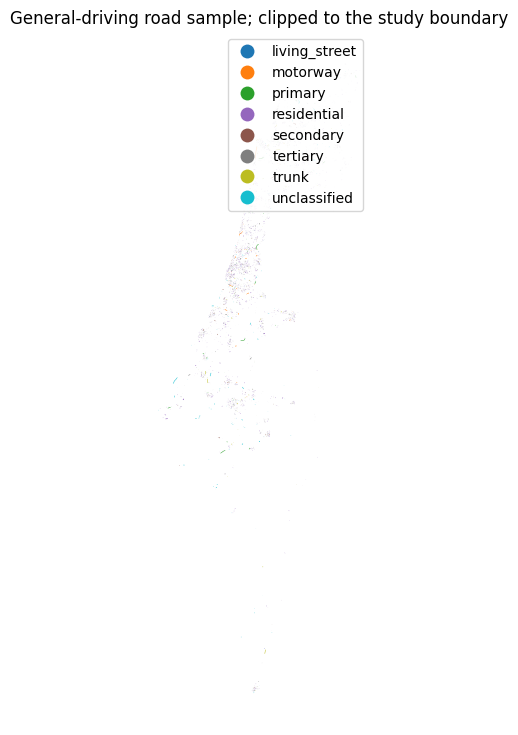

In [5]:
sample = roads[roads.is_general_driving].sample(
    min(5000, int(roads.is_general_driving.sum())), random_state=7
)
axis = sample.plot(column="road_class", linewidth=0.35, figsize=(7, 9), legend=True)
axis.set_title("General-driving road sample; clipped to the study boundary")
axis.set_axis_off()
plt.show()

**Caveat:** fragments are centerlines, not driveable polygons or a routing
graph. Nearest-road distance answers a proximity question; it does not prove
legal or connected vehicle access.